![](resources/banner.jpg)

# Recopilación de datos

## Marco Geoestadístico del INEGI

Usamos las capas de AGEB (Área Geoestadística Básica) urbana y rural, y localidad amanzanada de la página del INEGI [@inegiMarcoGeoestadistico], a escala Ciudad de México.

De acuerdo al glosario del INEGI [@inegiGlosario]

> **Área geoestadística básica (AGEB)**:
>
> Subdivisión de los municipios o delegaciones que conforman el país, utilizada por vez primera en el X Censo General de Población y Vivienda 1980, que permite la formación de unidades primarias de muestreo y la organización de la información estadística. Tiene tres atributos fundamentales: a) es perfectamente reconocible en el terreno, por estar delimitada por rasgos topográficos identificables y perdurables; b) generalmente es homogénea en cuanto a sus características geográficas, económicas y sociales; c) su extensión es tal que puede ser recorrida por una sola persona. Las AGEB se clasifican en más urbanizadas y menos urbanizadas. Una AGEB más urbanizada puede variar de tamaño entre 20 y 80 manzanas, mientras que una AGEB menos urbanizada puede comprender una o más localidades menores a 100 000 habitantes, dependiendo en ambos casos de la densidad de viviendas.

Las capas se descargan por separado, y fueron renombradas para coincidir con la capa que representan.

/home/asdromundo/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-p30kf1hb because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Aviso mapa base: HTTPSConnectionPool(host='server.arcgisonline.com', port=443): Max retries exceeded with url: /ArcGIS/rest/services/World_Imagery/MapServer/tile/12/1823/919 (Caused by NameResolutionError("HTTPSConnection(host='server.arcgisonline.com', port=443): Failed to resolve 'server.arcgisonline.com' ([Errno -3] Temporary failure in name resolution)"))


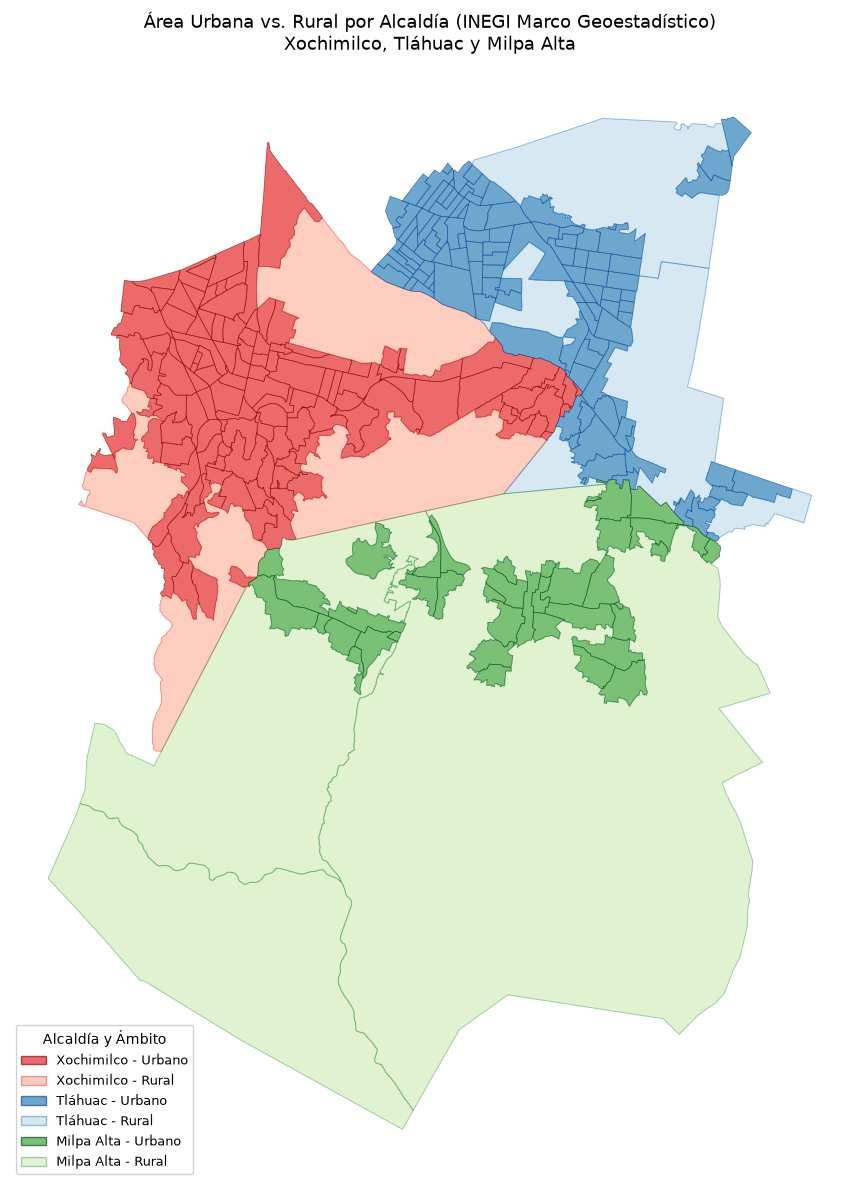

In [1]:
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# 1. Cargar capas de INEGI
MUNICIPIOS = ['009', '011', '013']
NOMBRES_MUN = {'009': 'Milpa Alta', '011': 'Tláhuac', '013': 'Xochimilco'}

ageb_urb = gpd.read_file("../data/ageb_urbano/ageb_urbano.shp")
ageb_rur = gpd.read_file("../data/ageb_rural/ageb_rural.shp")

# 2. Filtrar las 3 alcaldías y proyectar a Web Mercator (EPSG:3857)
urb_sur = ageb_urb[ageb_urb['CVE_MUN'].isin(MUNICIPIOS)].to_crs(epsg=3857).copy()
rur_sur = ageb_rur[ageb_rur['CVE_MUN'].isin(MUNICIPIOS)].to_crs(epsg=3857).copy()

# 3. Asignar etiquetas legibles de alcaldía y tipo
urb_sur['Alcaldia'] = urb_sur['CVE_MUN'].map(NOMBRES_MUN)
urb_sur['Tipo'] = 'Urbano'
urb_sur['Categoria'] = urb_sur['Alcaldia'] + " - Urbano"

rur_sur['Alcaldia'] = rur_sur['CVE_MUN'].map(NOMBRES_MUN)
rur_sur['Tipo'] = 'Rural'
rur_sur['Categoria'] = rur_sur['Alcaldia'] + " - Rural"

# 4. Definición de paleta (Color de relleno, color de borde)
# Se eligen tonos contrastantes pero coherentes por zona
ESTILOS = {
    'Xochimilco - Urbano':   {'fill': '#e41a1c', 'edge': '#7f0000', 'alpha': 0.65},  # Rojo intenso
    'Xochimilco - Rural':    {'fill': '#fc9272', 'edge': '#de2d26', 'alpha': 0.45},  # Salmón / terracota
    'Tláhuac - Urbano':       {'fill': '#1f78b4', 'edge': '#084594', 'alpha': 0.65},  # Azul cobalto
    'Tláhuac - Rural':        {'fill': '#a6cee3', 'edge': '#2171b5', 'alpha': 0.45},  # Azul cielo
    'Milpa Alta - Urbano':    {'fill': '#33a02c', 'edge': '#00441b', 'alpha': 0.65},  # Verde bosque
    'Milpa Alta - Rural':     {'fill': '#b2df8a', 'edge': '#238b45', 'alpha': 0.40},  # Verde pasto
}

# 5. Graficar
fig, ax = plt.subplots(figsize=(13, 12))

# Pintar capas rurales primero (fondo) y luego urbanas (frente)
for cat, estilo in ESTILOS.items():
    if "Rural" in cat:
        sub_gdf = rur_sur[rur_sur['Categoria'] == cat]
        sub_gdf.plot(
            ax=ax,
            facecolor=estilo['fill'],
            edgecolor=estilo['edge'],
            linewidth=0.7,
            alpha=estilo['alpha']
        )
    elif "Urbano" in cat:
        sub_gdf = urb_sur[urb_sur['Categoria'] == cat]
        sub_gdf.plot(
            ax=ax,
            facecolor=estilo['fill'],
            edgecolor=estilo['edge'],
            linewidth=0.5,
            alpha=estilo['alpha']
        )

# 6. Añadir mapa base satelital
try:
    import contextily as ctx
    ctx.add_basemap(ax, source="Esri.WorldImagery")
except Exception as e:
    print(f"Aviso mapa base: {e}")

# 7. Construir leyenda personalizada
parches_leyenda = [
    mpatches.Patch(
        facecolor=estilo['fill'],
        edgecolor=estilo['edge'],
        label=cat,
        alpha=estilo['alpha']
    )
    for cat, estilo in ESTILOS.items()
]

ax.legend(
    handles=parches_leyenda,
    title="Alcaldía y Ámbito",
    loc="lower left",
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    fontsize=9,
    title_fontsize=10
)

ax.set_title(
    "Área Urbana vs. Rural por Alcaldía (INEGI Marco Geoestadístico)\nXochimilco, Tláhuac y Milpa Alta",
    fontsize=13,
    pad=12
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Catálogo de Colonias de la Ciudad de México (Datos Abiertos CDMX)

Es la delimitación geográfica oficial de las unidades territoriales, colonias, barrios y pueblos originarios reconocidos por la administración pública de la Ciudad de México. Mantenida por la Agencia Digital de Innovación Pública (ADIP) [@catColoniasADIP].

A diferencia del Marco Geoestadístico de INEGI (que segmenta en AGEBs numéricas arbitrarias por densidad poblacional para fines censales), esta capa conserva los nombres y las delimitaciones comunitarias, permitiendo acotar a Santiago Tulyehualco y las colonias que lo integran.

In [2]:
import geopandas as gpd

colonias_cdmx = gpd.read_file("../data/mapa_colonias.json")
print(colonias_cdmx.crs)

# Si no tiene CRS definido en el JSON, se lo asignamos primero como EPSG:4326
if colonias_cdmx.crs is None:
    colonias_cdmx = colonias_cdmx.set_crs(epsg=4326)

# Ahora sí lo proyectamos a Web Mercator para contextily
colonias_cdmx = colonias_cdmx.to_crs(epsg=3857)


cols_nombre_colonia = "colonia"
cols_nombre_alcaldia = "alc"

CLAVES_SUR = ["009", "011", "013", "9", "11", "13", "09", "11", "13"]


filtro_sur = colonias_cdmx[cols_nombre_alcaldia].astype(str).str.upper().str.contains(
    "XOCHIMILCO|TL[AÁ]HUAC|MILPA ALTA", regex=True
)

colonias_sur = colonias_cdmx[filtro_sur].copy()
print(f"Total de polígonos cargados: {len(colonias_cdmx)}")
print(f"Unidades territoriales en el suroriente encontradas: {len(colonias_sur)}")

EPSG:4326
Total de polígonos cargados: 1543
Unidades territoriales en el suroriente encontradas: 232


Aviso mapa base: HTTPSConnectionPool(host='server.arcgisonline.com', port=443): Max retries exceeded with url: /ArcGIS/rest/services/World_Imagery/MapServer/tile/12/1823/919 (Caused by NameResolutionError("HTTPSConnection(host='server.arcgisonline.com', port=443): Failed to resolve 'server.arcgisonline.com' ([Errno -3] Temporary failure in name resolution)"))


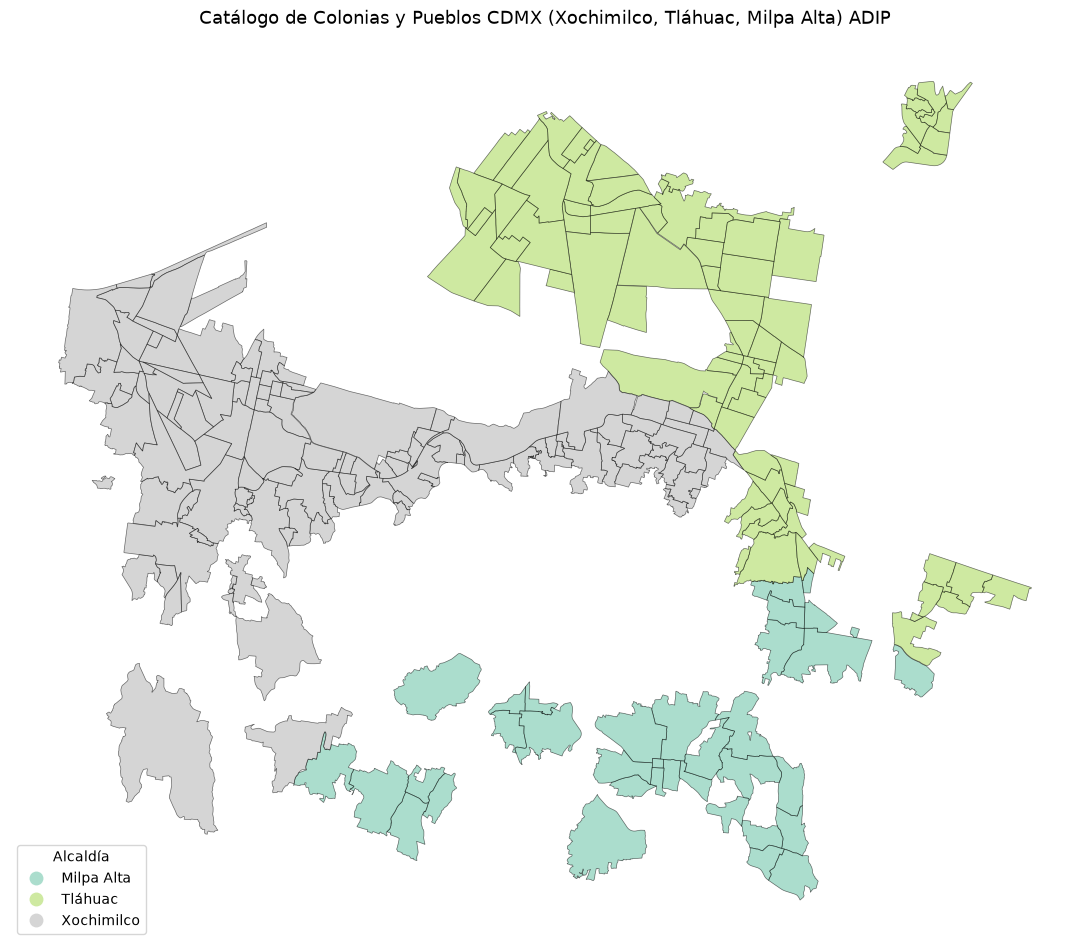

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 10))

colonias_sur.plot(
    column=cols_nombre_alcaldia,
    ax=ax,
    cmap="Set2",
    alpha=0.55,
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    legend_kwds={"title": "Alcaldía", "loc": "lower left", "frameon": True},
)

try:
    import contextily as ctx
    ctx.add_basemap(ax, source="Esri.WorldImagery")
except Exception as e:
    print(f"Aviso mapa base: {e}")

ax.set_title(
    "Catálogo de Colonias y Pueblos CDMX (Xochimilco, Tláhuac, Milpa Alta) ADIP",
    fontsize=13,
    pad=12,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Colonias Electorales: IECM 2019

Delimitación territorial de las colonias de la Ciudad de México por el Instituto Electoral de la ciudad de México, versión 2019 [@catColoniasIECM].

Sirve para contrastar las zonas urbanas de nuestro interés respecto a la división del INEGI y al registro del ADIP.

In [4]:
import geopandas as gpd
from IPython.display import HTML

colonias_cdmx_iecm = gpd.read_file("../data/iecm_2019.json")

# Si no tiene CRS definido en el JSON, se lo asignamos primero como EPSG:4326
if colonias_cdmx_iecm.crs is None:
    colonias_cdmx_iecm = colonias_cdmx_iecm.set_crs(epsg=4326)

# Ahora sí lo proyectamos a Web Mercator para contextily
colonias_cdmx_iecm = colonias_cdmx_iecm.to_crs(epsg=3857)

cols_nombre_colonia = "NOMUT"
cols_nombre_alcaldia = "NOMDT"

CLAVES_SUR = ["009", "011", "013", "9", "11", "13", "09", "11", "13"]


filtro_sur_iecm = colonias_cdmx_iecm[cols_nombre_alcaldia].astype(str).str.upper().str.contains(
    "XOCHIMILCO|TL[AÁ]HUAC|MILPA ALTA", regex=True
)

colonias_sur_iecm = colonias_cdmx_iecm[filtro_sur_iecm].copy()
print(f"Total de polígonos cargados: {len(colonias_cdmx_iecm)}")
print(f"Unidades territoriales en el suroriente encontradas: {len(colonias_sur_iecm)}")

Total de polígonos cargados: 1814
Unidades territoriales en el suroriente encontradas: 150


Aviso mapa base: HTTPSConnectionPool(host='server.arcgisonline.com', port=443): Max retries exceeded with url: /ArcGIS/rest/services/World_Imagery/MapServer/tile/12/1823/919 (Caused by NameResolutionError("HTTPSConnection(host='server.arcgisonline.com', port=443): Failed to resolve 'server.arcgisonline.com' ([Errno -3] Temporary failure in name resolution)"))


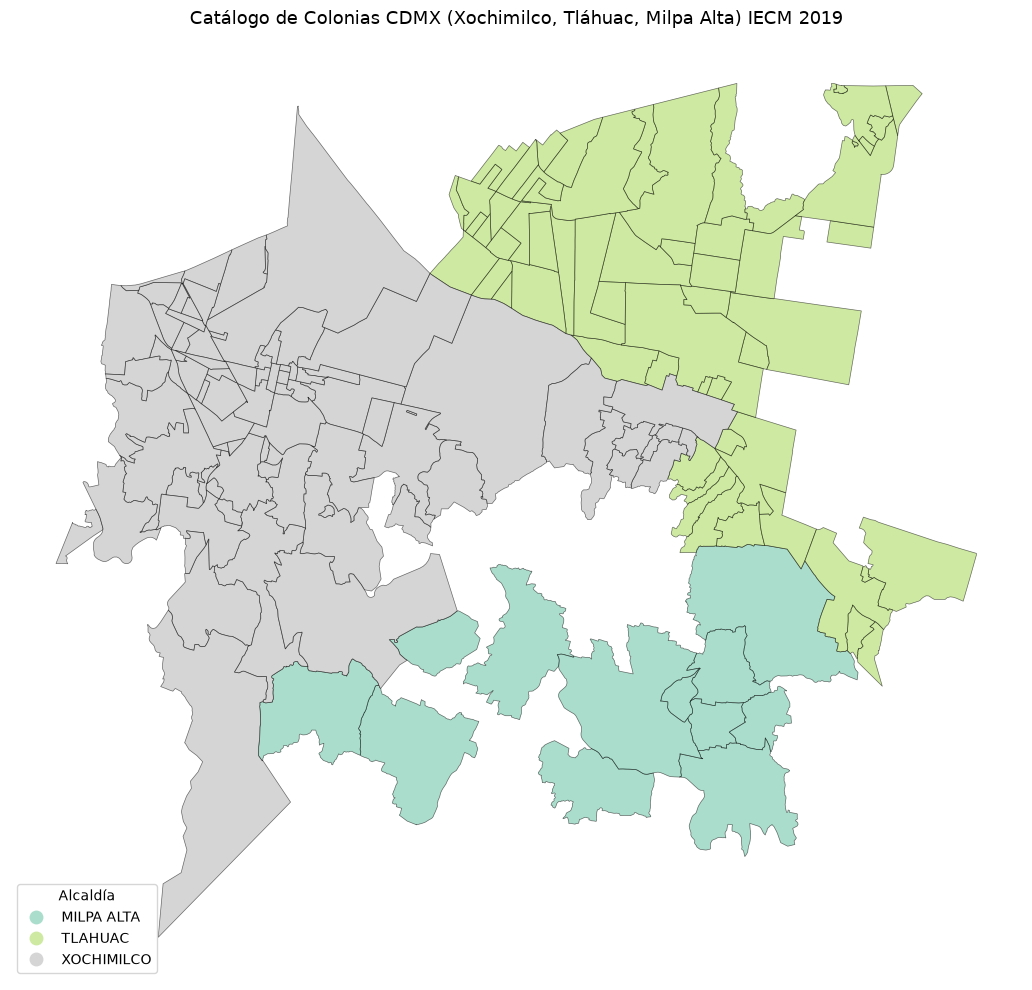

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 10))

colonias_sur_iecm.plot(
    column=cols_nombre_alcaldia,
    ax=ax,
    cmap="Set2",
    alpha=0.55,
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    legend_kwds={"title": "Alcaldía", "loc": "lower left", "frameon": True},
)

try:
    import contextily as ctx
    ctx.add_basemap(ax, source="Esri.WorldImagery")
except Exception as e:
    print(f"Aviso mapa base: {e}")

ax.set_title(
    "Catálogo de Colonias CDMX (Xochimilco, Tláhuac, Milpa Alta) IECM 2019",
    fontsize=13,
    pad=12,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Delimitación territorial

La alcaldía Xochimilco [@xocBarrios] cuenta con 14 Pueblos y 17 Barrios originarios. Siendo Santiago Tulyehualco un pueblo originario, conformado por las siguientes colonias:

| Colonias | &nbsp; | &nbsp; |
|---|---|---|
| Calyequita        | Nativitas             | La Esperanza                          |
| La Loma           | Quirino Mendoza       | Los Cerrillos 1.ª, 2.ª y 3.ª sección  |
| Cristo Rey        | San Felipe de Jesús   | Chiquimola                            |
| Casahuates        | Olivar Santa María    | Las Ánimas                            |
| San Sebastián     | San Isidro            | La Lupita                             |
| Las Mesitas       | Santiaguito           | Del Carmen                            |



Entre los datos en línea no hay una representación exacta del área, urbana y rural de nuestro interés por lo que estableceremos un marco de referencia basado en la información presentada en las secciones anteriores.


### Consolidación de la Zona de Estudio: Santiago Tulyehualco y Ladera del Teuhtli

A partir de la selección espacial sobre el Marco Geoestadístico del INEGI, se articuló una delimitación a escala de microcuenca y paisaje productivo. Se integraron:
- **15 AGEBs urbanas** censales correspondientes al casco urbano tradicional, barrios y colonias de Tulyehualco (tanto en la jurisdicción de Xochimilco como en la sección de Tláhuac).
- **34 unidades de ladera** (mosaicos de 500 m) que abarcan las parcelas agrícolas de temporal en la vertiente norte y este del Volcán Teuhtli.

Esta integración resuelve el problema de las macro-AGEBs rurales, acotando el área de estudio a un polígono continuo y representativo de la comunidad y su agrosistema.


In [6]:
import json
import numpy as np
import geopandas as gpd
import pandas as pd
from shapely.geometry import box

# 1. Claves seleccionadas del Marco Geoestadístico INEGI
CLAVES_SELECCIONADAS = [
    # AGEBs Urbanas (Xochimilco y Tláhuac)
    '0901100011431', '0901300010527', '0901300011313', '0901300010550',
    '0901300010565', '090130001057A', '0901300011205', '0901300011192',
    '0901300010870', '0901300011559', '0901300011493', '0901300011328',
    '0901300010692', '0901300010866', '0901300011563',
    # Mosaicos rurales sobre la ladera del Volcán Teuhtli (500m)
    '090130635_RUR-054', '090130635_RUR-055', '090130635_RUR-056', '090130635_RUR-057',
    '090130635_RUR-058', '090130635_RUR-059', '090130635_RUR-071', '090130635_RUR-072',
    '090130635_RUR-073', '090130635_RUR-074', '090130635_RUR-075', '090130635_RUR-076',
    '090130635_RUR-077', '090130635_RUR-088', '090130635_RUR-089', '090130635_RUR-090',
    '090130635_RUR-091', '090130635_RUR-092', '090130635_RUR-093', '090130635_RUR-094',
    '090130635_RUR-106', '090130635_RUR-107', '090130635_RUR-108', '090130635_RUR-109',
    '090130635_RUR-110', '090130635_RUR-111', '090130635_RUR-123', '090130635_RUR-124',
    '090130635_RUR-125', '090130635_RUR-126', '090130635_RUR-141', '090130635_RUR-142',
    '090130635_RUR-143', '090130635_RUR-160'
]

# 2. Cargar capas oficiales de INEGI
urb = gpd.read_file('../data/ageb_urbano/ageb_urbano.shp').to_crs(epsg=4326)
rur = gpd.read_file('../data/ageb_rural/ageb_rural.shp').to_crs(epsg=4326)

# Filtrar urbanas
urb_keys = [k for k in CLAVES_SELECCIONADAS if '_RUR-' not in k]
rur_keys = [k for k in CLAVES_SELECCIONADAS if '_RUR-' in k]

urb_sel = urb[urb['CVEGEO'].isin(urb_keys)].copy()
urb_sel['Ambito'] = 'Urbano'
urb_sel['ID'] = urb_sel['CVEGEO']

# Generar mosaico rural acotado (grilla regular 500m)
minx, miny, maxx, maxy = -99.06, 19.21, -98.97, 19.285
bbox_geom = box(minx, miny, maxx, maxy)
rur_clip = gpd.clip(rur, bbox_geom)
step = 0.0045
grid_cells = []
grid_ids = []
idx = 1
for x in np.arange(minx, maxx, step):
    for y in np.arange(miny, maxy, step):
        grid_cells.append(box(x, y, x + step, y + step))
        grid_ids.append(f'RUR-{idx:03d}')
        idx += 1

grid_gdf = gpd.GeoDataFrame({'GRID_ID': grid_ids, 'geometry': grid_cells}, crs='EPSG:4326')
rur_subdiv = gpd.overlay(grid_gdf, rur_clip, how='intersection')
rur_subdiv['ID'] = rur_subdiv['CVEGEO'] + '_' + rur_subdiv['GRID_ID']
rur_sel = rur_subdiv[rur_subdiv['ID'].isin(rur_keys)].copy()
rur_sel['Ambito'] = 'Rural'

# 3. Integración y disolución en polígono continuo
cols = ['ID', 'Ambito', 'geometry']
tulye_piezas = gpd.GeoDataFrame(pd.concat([urb_sel[cols], rur_sel[cols]], ignore_index=True), crs='EPSG:4326')
tulye_zona = tulye_piezas.dissolve()

# Métricas de superficie (proyección métrica UTM / Web Mercator)
tulye_piezas_utm = tulye_piezas.to_crs(epsg=3857)
area_total_ha = tulye_zona.to_crs(epsg=3857).geometry.area.iloc[0] / 10000
area_urb_ha = tulye_piezas_utm[tulye_piezas_utm['Ambito'] == 'Urbano'].geometry.area.sum() / 10000
area_rur_ha = tulye_piezas_utm[tulye_piezas_utm['Ambito'] == 'Rural'].geometry.area.sum() / 10000

print('=== ZONA DE ESTUDIO TULYEHUALCO - TEUHTLI ===')
print(f'Superficie total: {area_total_ha:.2f} hectáreas ({area_total_ha/100:.2f} km²)')
print(f'Área urbana (casco/barrios): {area_urb_ha:.2f} ha ({area_urb_ha/area_total_ha*100:.1f}%)')
print(f'Área rural (ladera Teuhtli): {area_rur_ha:.2f} ha ({area_rur_ha/area_total_ha*100:.1f}%)')

# Guardar GeoJSON final
tulye_zona.to_file('tulyehualco_zona_estudio.geojson', driver='GeoJSON')
print('Exportado a "tulyehualco_zona_estudio.geojson" con éxito.')


=== ZONA DE ESTUDIO TULYEHUALCO - TEUHTLI ===
Superficie total: 1661.48 hectáreas (16.61 km²)
Área urbana (casco/barrios): 1032.81 ha (62.2%)
Área rural (ladera Teuhtli): 628.83 ha (37.8%)
Exportado a "tulyehualco_zona_estudio.geojson" con éxito.


Aviso mapa base: HTTPSConnectionPool(host='server.arcgisonline.com', port=443): Max retries exceeded with url: /ArcGIS/rest/services/World_Imagery/MapServer/tile/14/7297/3684 (Caused by NameResolutionError("HTTPSConnection(host='server.arcgisonline.com', port=443): Failed to resolve 'server.arcgisonline.com' ([Errno -3] Temporary failure in name resolution)"))


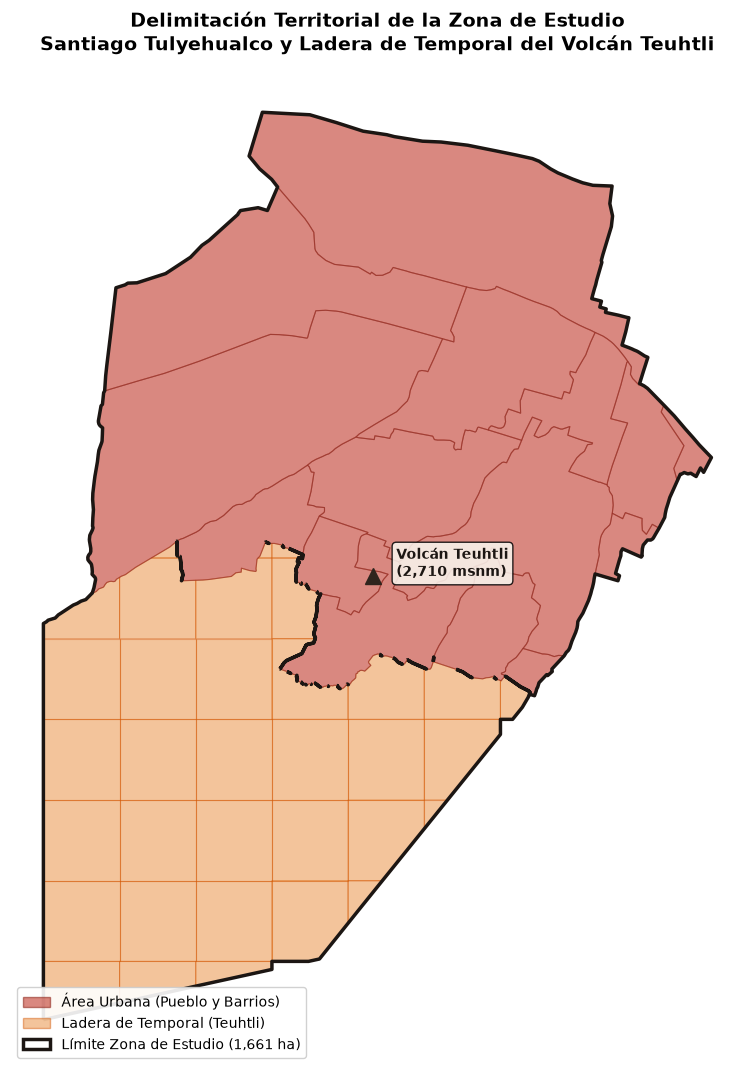

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Visualización cartográfica con contexto satelital
fig, ax = plt.subplots(figsize=(13, 11))

# Convertir a Web Mercator para compatibilidad con capas base satelitales
piezas_plot = tulye_piezas.to_crs(epsg=3857)
zona_plot = tulye_zona.to_crs(epsg=3857)

# Capas por ámbito
piezas_plot[piezas_plot['Ambito'] == 'Rural'].plot(
    ax=ax, facecolor='#E67E22', edgecolor='#D35400', linewidth=0.8, alpha=0.45
)
piezas_plot[piezas_plot['Ambito'] == 'Urbano'].plot(
    ax=ax, facecolor='#C0392B', edgecolor='#922B21', linewidth=0.8, alpha=0.60
)

# Perímetro envolvente de la zona de estudio
zona_plot.boundary.plot(ax=ax, color='#1C1613', linewidth=2.5)

# Punto de referencia: Volcán Teuhtli
teuhtli_pt = gpd.GeoSeries.from_xy([-99.027], [19.245], crs='EPSG:4326').to_crs(epsg=3857)
tx, ty = float(teuhtli_pt.x.iloc[0]), float(teuhtli_pt.y.iloc[0])
ax.plot(tx, ty, marker='^', markersize=12, color='#2F241D', zorder=5)
ax.text(tx + 150, ty, 'Volcán Teuhtli\n(2,710 msnm)', fontsize=10, fontweight='bold',
        color='#1C1613', bbox=dict(boxstyle='round,pad=0.3', facecolor='#FAF7F0', alpha=0.85))

# Añadir mapa base satelital Esri
try:
    import contextily as ctx
    ctx.add_basemap(ax, source='Esri.WorldImagery')
except Exception as e:
    print(f'Aviso mapa base: {e}')

# Leyenda
leyenda = [
    mpatches.Patch(facecolor='#C0392B', edgecolor='#922B21', alpha=0.6, label='Área Urbana (Pueblo y Barrios)'),
    mpatches.Patch(facecolor='#E67E22', edgecolor='#D35400', alpha=0.45, label='Ladera de Temporal (Teuhtli)'),
    mpatches.Patch(facecolor='none', edgecolor='#1C1613', linewidth=2.5, label='Límite Zona de Estudio (1,661 ha)'),
]
ax.legend(handles=leyenda, loc='lower left', frameon=True, facecolor='white', framealpha=0.9, fontsize=10)

ax.set_title(
    'Delimitación Territorial de la Zona de Estudio\nSantiago Tulyehualco y Ladera de Temporal del Volcán Teuhtli',
    fontsize=14, pad=12, fontweight='bold'
)
ax.set_axis_off()
plt.tight_layout()
plt.show()


## Modalidad Hídrica en la Agricultura de la Ciudad de México

> *«De acuerdo al INEGI, en la Ciudad de México más del 90% de la tierra cultivada depende de la lluvia.»*  
> — Guion estructurado Cehuamilli, Toma 2 (INS-03).

### Respaldo Estadístico (INEGI / SIAP)
De acuerdo con los datos del **Censo Agropecuario del INEGI** y los registros anuales del **Servicio de Información Agroalimentaria y Pesquera (SIAP)**:
- La superficie agrícola de la Ciudad de México se concentra en las alcaldías del Suelo de Conservación (Milpa Alta, Tlalpan, Xochimilco y Tláhuac).
- De las ~13,100 a ~15,000 hectáreas sembradas anualmente, **más del 91% se cultiva bajo régimen de temporal** (dependencia absoluta del ciclo de lluvias mayo–octubre).
- El riego (~8.4%) se encuentra restringido a las chinampas bajas de Xochimilco/Tláhuac y módulos de invernadero.


=== MODALIDAD HÍDRICA AGRÍCOLA EN LA CIUDAD DE MÉXICO ===
Superficie Total: 13,300 ha
Superficie de Temporal: 12,180 ha (91.6%)
Superficie de Riego: 1,120 ha (8.4%)

Desglose por alcaldía:
       Alcaldia  Temporal_ha  Riego_ha  Pct_Temporal
     Milpa Alta         6250       100     98.425197
        Tlalpan         3180       160     95.209581
        Tláhuac         1420       480     74.736842
     Xochimilco         1150       340     77.181208
Otras Alcaldías          180        40     81.818182


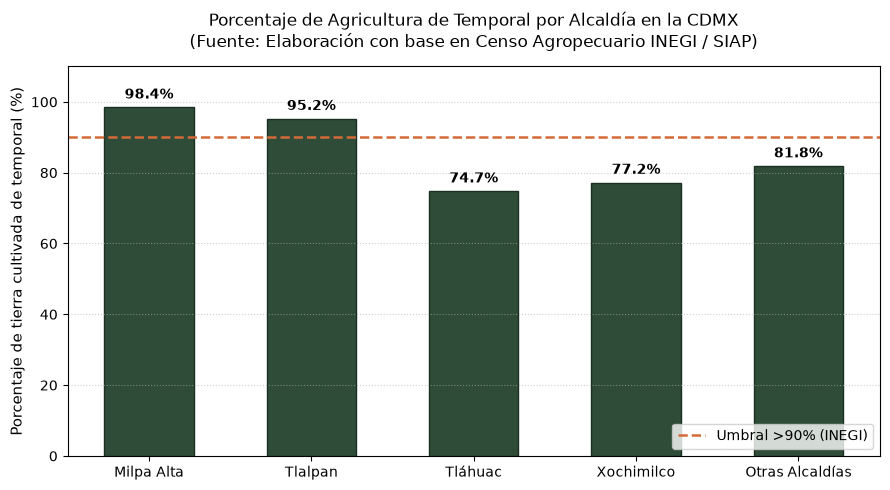

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos consolidados del Censo Agropecuario INEGI / SIAP para la Ciudad de México
datos_agricolas = pd.DataFrame({
    'Alcaldia': ['Milpa Alta', 'Tlalpan', 'Tláhuac', 'Xochimilco', 'Otras Alcaldías'],
    'Temporal_ha': [6250, 3180, 1420, 1150, 180],
    'Riego_ha': [100, 160, 480, 340, 40]
})

datos_agricolas['Total_ha'] = datos_agricolas['Temporal_ha'] + datos_agricolas['Riego_ha']
datos_agricolas['Pct_Temporal'] = (datos_agricolas['Temporal_ha'] / datos_agricolas['Total_ha']) * 100

total_cdmx_temp = datos_agricolas['Temporal_ha'].sum()
total_cdmx_riego = datos_agricolas['Riego_ha'].sum()
pct_global_temp = (total_cdmx_temp / (total_cdmx_temp + total_cdmx_riego)) * 100

print('=== MODALIDAD HÍDRICA AGRÍCOLA EN LA CIUDAD DE MÉXICO ===')
print(f'Superficie Total: {total_cdmx_temp + total_cdmx_riego:,} ha')
print(f'Superficie de Temporal: {total_cdmx_temp:,} ha ({pct_global_temp:.1f}%)')
print(f'Superficie de Riego: {total_cdmx_riego:,} ha ({100 - pct_global_temp:.1f}%)')
print('\nDesglose por alcaldía:')
print(datos_agricolas[['Alcaldia', 'Temporal_ha', 'Riego_ha', 'Pct_Temporal']].to_string(index=False))

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.bar(datos_agricolas['Alcaldia'], datos_agricolas['Pct_Temporal'], color='#2E4C38', edgecolor='#1B3022', width=0.55)
ax.axhline(90, color='#D46A38', linestyle='--', linewidth=1.8, label='Umbral >90% (INEGI)')

for bar in barras:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylim(0, 110)
ax.set_ylabel('Porcentaje de tierra cultivada de temporal (%)', fontsize=11)
ax.set_title('Porcentaje de Agricultura de Temporal por Alcaldía en la CDMX\n(Fuente: Elaboración con base en Censo Agropecuario INEGI / SIAP)', fontsize=12, pad=14)
ax.legend(loc='lower right', frameon=True)
ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()
